# Analisis Aktor Jaringan KSO Agrinas — Visualisasi

**Unit II Harda — Ditreskrimum Polda Riau**  
**Sumber:** `jaringan_kso_agrinas.gexf`  
**Produk:** Notebook analisis visual siap briefing  

> Deskripsi–sintesis analitik. Bukan verifikasi lapangan / perintah operasi.

Notebook ini menampilkan metrik jaringan, skor hub risiko, peta jaringan, heatmap aktor–Polres, dan ego-network aktor prioritas.


## 1. Setup


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(r"C:\Users\Patron\Downloads\sawit lagi")
sys.path.insert(0, str(ROOT / "notebooks"))

from analisis_aktor_kso_harda import (
    UNIT, JUDUL, GEXF, OUT,
    load_graph, compute_metrics, score_hubs,
    actor_polres_matrix, ego_polres_summary, communities,
    write_findings, PAM_SEED,
)
from viz_aktor_kso import (
    plot_skor_hub, plot_betweenness, plot_degree_vs_betweenness,
    plot_heatmap_aktor_polres, plot_band_distribution, plot_ego_polres,
    plot_network, plot_ego_aktor, plot_dashboard,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 140)

print(JUDUL)
print(UNIT)
print("GEXF:", GEXF, "| exists:", GEXF.exists())
print("Output:", OUT)


Analisis Aktor Jaringan KSO Agrinas
Unit II Harda — Ditreskrimum Polda Riau
GEXF: C:\Users\Patron\Downloads\sawit lagi\jaringan_kso_agrinas.gexf | exists: True
Output: C:\Users\Patron\Downloads\sawit lagi\output\aktor_kso


## 2. Load graf & hitung metrik


In [2]:
G = load_graph()
metrics = compute_metrics(G)
hubs = score_hubs(metrics)
mat = actor_polres_matrix(G)
ego = ego_polres_summary(G, metrics)
comm = communities(G)
if not comm.empty:
    metrics = metrics.merge(comm, on="aktor_id", how="left")

print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
print(f"Aktor (non-generik): {(metrics.bucket.isin(['aktor','agrinas']) & (metrics.generic_flag!='YA')).sum()}")
print(f"Watchlist prioritas: {(hubs.prioritas_pantau=='YA').sum()}")
hubs.head(12)


Nodes: 73 | Edges: 111
Aktor (non-generik): 20
Watchlist prioritas: 15


,aktor_id,label,ntype,skor_hub,skor_struktural,boost_dampak,band_hub,prioritas_pantau,degree,betweenness,jml_polres_terkait,jml_estate_tetangga,jml_estate_merah_tetangga,pam_non_bujp_flag,hub_risiko_flag,polres_list,peran
0,Agrinas Palma Nusantara,Agrinas Palma Nusantara,agrinas,100.0,100.0,0.0,REFERENSI,TIDAK,32,0.8801,5,11,0,TIDAK,YA,"Inhu, Kampar, Kuansing, Pelalawan, Rohul",
1,Bernas Mulya Mandiri,Bernas Mulya Mandiri,aktor_multi,75.0,75.0,0.0,KRITIS,YA,6,0.0852,2,5,0,TIDAK,YA,"Inhu, Rohul",penerima_kso
2,PT Nusantara Sawit Majuma,PT Nusantara Sawit Majuma,aktor_pam,74.1,39.1,35.0,KRITIS,YA,2,0.0237,1,1,1,YA,YA,Rohul,"pam_or_kso_flagged, penerima_kso"
3,PT Ujung Tanjung Sejahtera,PT Ujung Tanjung Sejahtera,aktor_pam,73.6,48.6,25.0,KRITIS,YA,2,0.0548,1,1,1,YA,YA,Rohil,"pam_or_kso_flagged, penerima_kso"
4,PT Palma Agung Betuah (PAB),PT Palma Agung Betuah (PA…,aktor_pam,70.6,42.6,28.0,KRITIS,YA,2,0.0351,1,1,1,YA,YA,Bengkalis,"pam_or_kso_flagged, penerima_kso"
5,PT Riden Jaya Konstruksi,PT Riden Jaya Konstruksi,aktor_pam,51.5,33.5,18.0,TINGGI,YA,2,0.0381,1,1,0,YA,YA,Dumai,penerima_kso
6,Berlian Nusantara Perkasa,Berlian Nusantara Perkasa,aktor_multi,40.8,40.8,0.0,SEDANG,YA,4,0.0679,1,3,0,TIDAK,YA,Pelalawan,penerima_kso
7,Poktan Riau Jaya Makmur,Poktan Riau Jaya Makmur,aktor_pam,40.5,40.5,0.0,SEDANG,YA,3,0.0477,1,2,0,YA,YA,Kampar,"pam_or_kso_flagged, penerima_kso"
8,Poktan Berkah Tani Sejahtera,Poktan Berkah Tani Sejaht…,aktor_multi,35.7,35.7,0.0,SEDANG,YA,3,0.0812,1,2,0,TIDAK,YA,Inhil,penerima_kso
9,PT Runggu,PT Runggu,aktor_multi,25.5,25.5,0.0,RENDAH,YA,3,0.0476,1,2,0,TIDAK,YA,Inhu,penerima_kso


## 3. Dashboard visual ringkas

Cuplikan satu layar untuk briefing Kanit / Kasubdit.


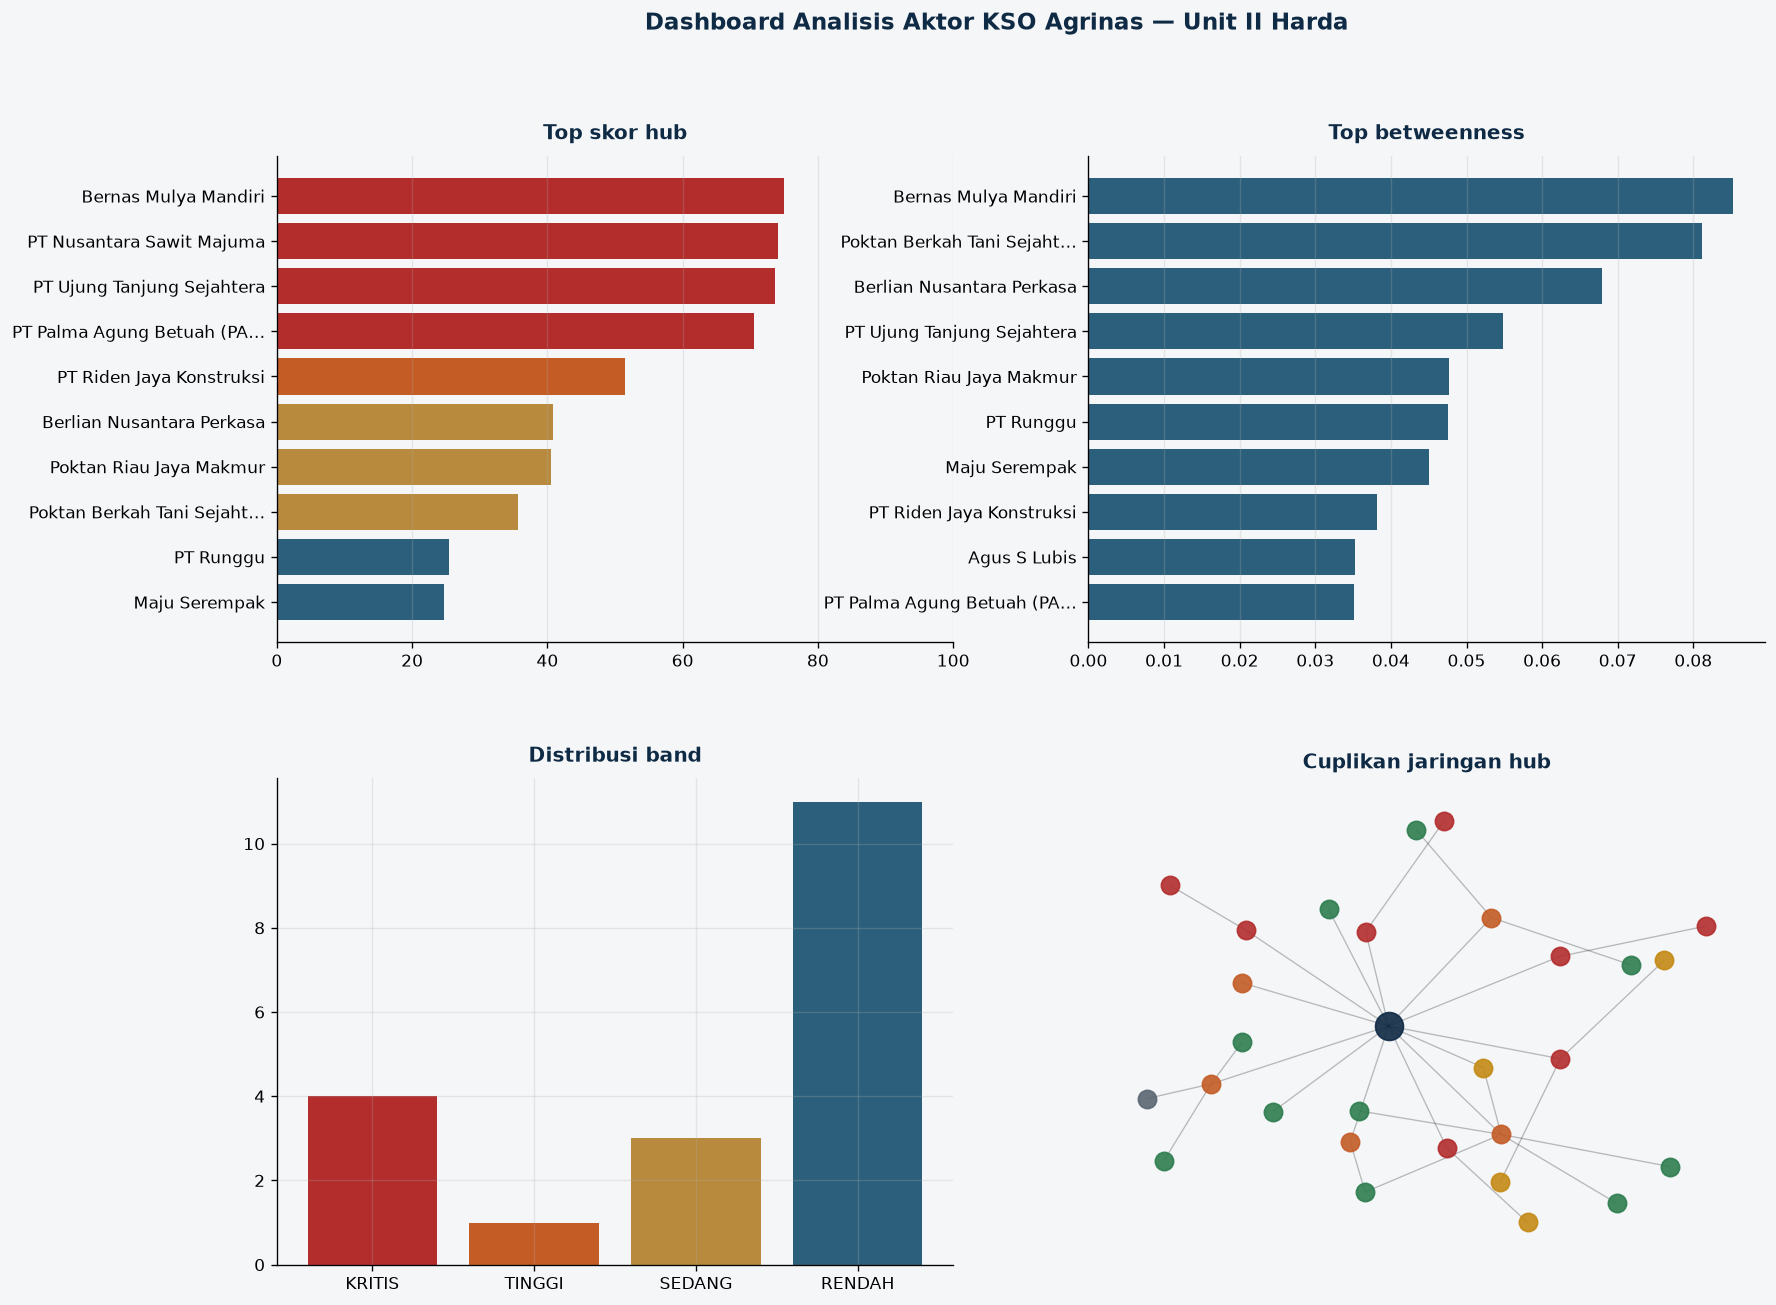

In [3]:
fig = plot_dashboard(G, hubs, metrics, mat, ego)
fig.savefig(OUT / "fig_dashboard.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


## 4. Ranking skor hub risiko

Skor = struktural jaringan + boost dampak pilot R4 (Majuma/PAB/UTS/Riden).  
Band: **KRITIS ≥70 · TINGGI ≥50 · SEDANG ≥30 · RENDAH <30**.


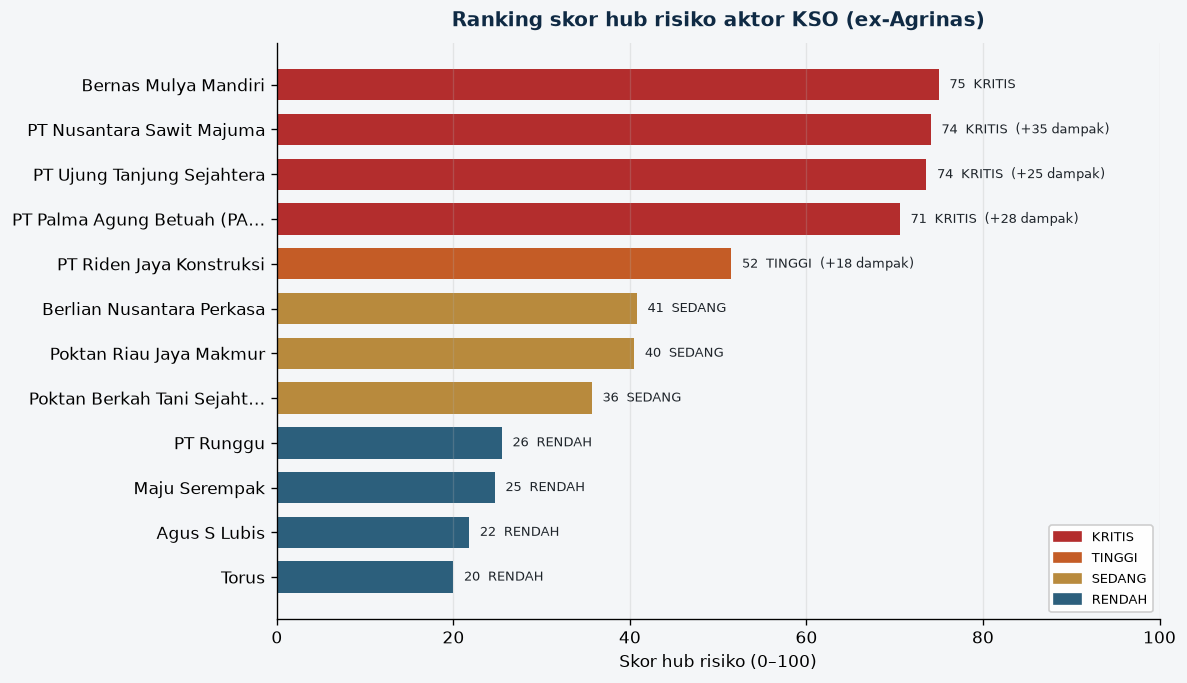

,aktor_id,skor_hub,skor_struktural,boost_dampak,band_hub,jml_polres_terkait,jml_estate_tetangga,pam_non_bujp_flag,polres_list
1,Bernas Mulya Mandiri,75.0,75.0,0.0,KRITIS,2,5,TIDAK,"Inhu, Rohul"
2,PT Nusantara Sawit Majuma,74.1,39.1,35.0,KRITIS,1,1,YA,Rohul
3,PT Ujung Tanjung Sejahtera,73.6,48.6,25.0,KRITIS,1,1,YA,Rohil
4,PT Palma Agung Betuah (PAB),70.6,42.6,28.0,KRITIS,1,1,YA,Bengkalis
5,PT Riden Jaya Konstruksi,51.5,33.5,18.0,TINGGI,1,1,YA,Dumai
6,Berlian Nusantara Perkasa,40.8,40.8,0.0,SEDANG,1,3,TIDAK,Pelalawan
7,Poktan Riau Jaya Makmur,40.5,40.5,0.0,SEDANG,1,2,YA,Kampar
8,Poktan Berkah Tani Sejahtera,35.7,35.7,0.0,SEDANG,1,2,TIDAK,Inhil
9,PT Runggu,25.5,25.5,0.0,RENDAH,1,2,TIDAK,Inhu
10,Maju Serempak,24.7,24.7,0.0,RENDAH,1,2,TIDAK,Pelalawan


In [4]:
fig = plot_skor_hub(hubs, top_n=12)
fig.savefig(OUT / "fig_degree_hub.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

watch = hubs[hubs["prioritas_pantau"] == "YA"][
    ["aktor_id", "skor_hub", "skor_struktural", "boost_dampak", "band_hub",
     "jml_polres_terkait", "jml_estate_tetangga", "pam_non_bujp_flag", "polres_list"]
]
watch


## 5. Betweenness — aktor penjembatan

Betweenness tinggi = aktor yang sering berada di jalur terpendek antar node → indikasi potensi penularan risiko antar kebun/Polres.


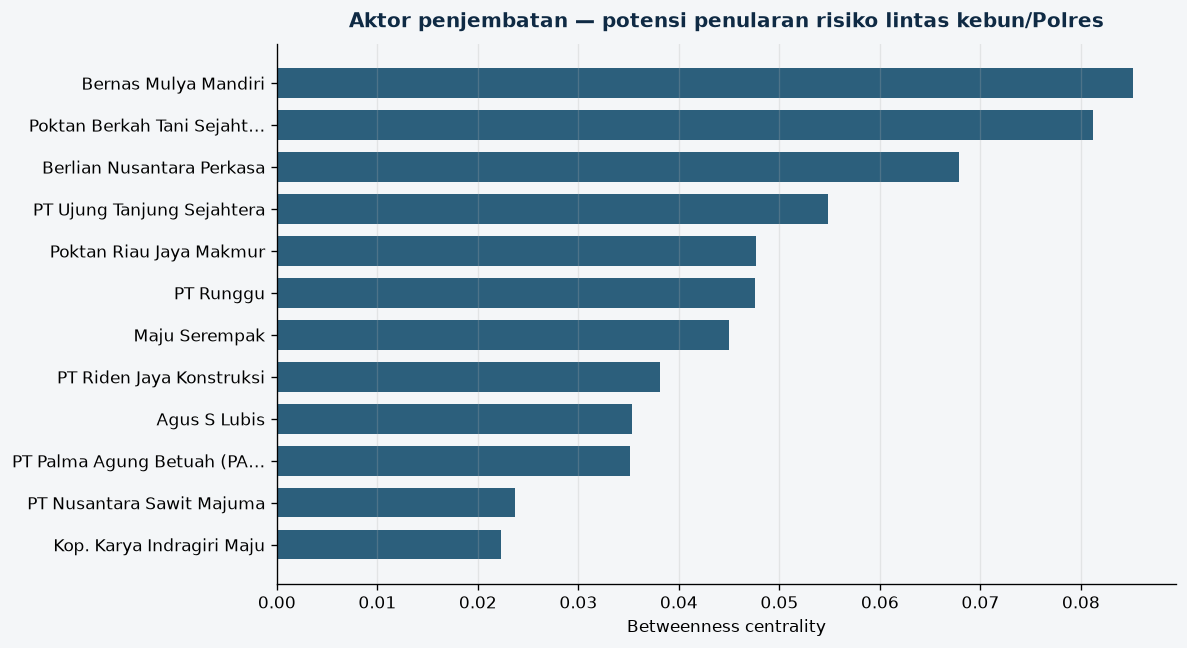

In [5]:
fig = plot_betweenness(metrics, top_n=12)
fig.savefig(OUT / "fig_betweenness.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


## 6. Peta posisi: degree × betweenness

Ukuran titik ~ skor hub. Label ditampilkan untuk aktor skor ≥40 atau berflag PAM.


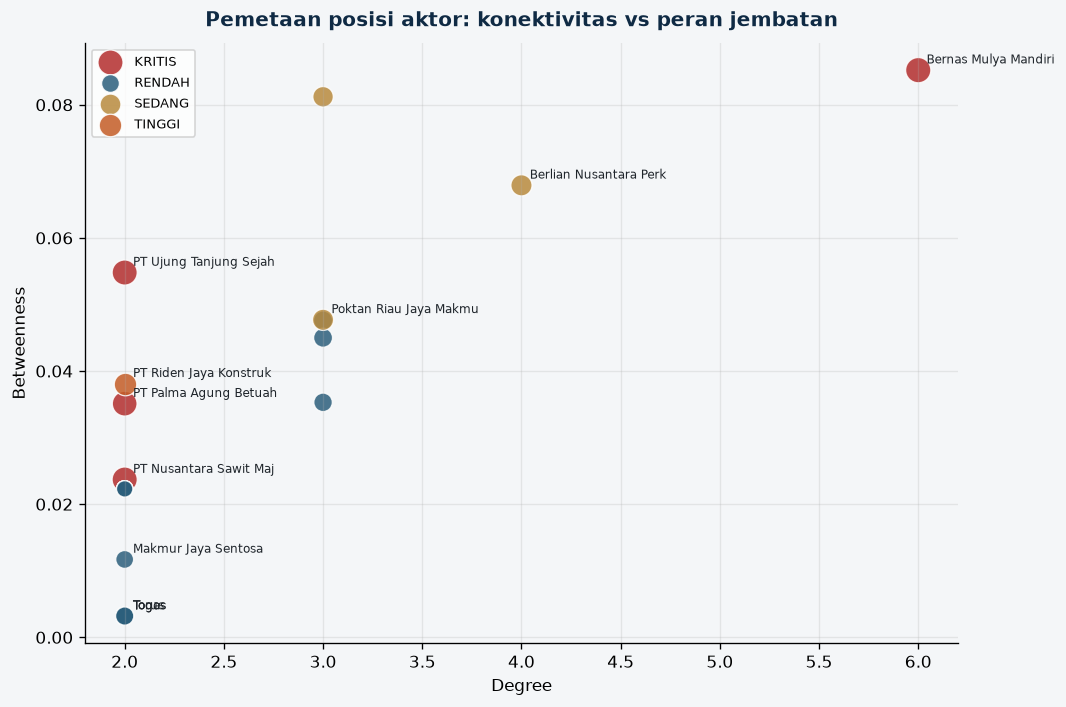

In [6]:
fig = plot_degree_vs_betweenness(hubs)
fig.savefig(OUT / "fig_scatter_degree_betweenness.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


## 7. Distribusi band & beban per Polres


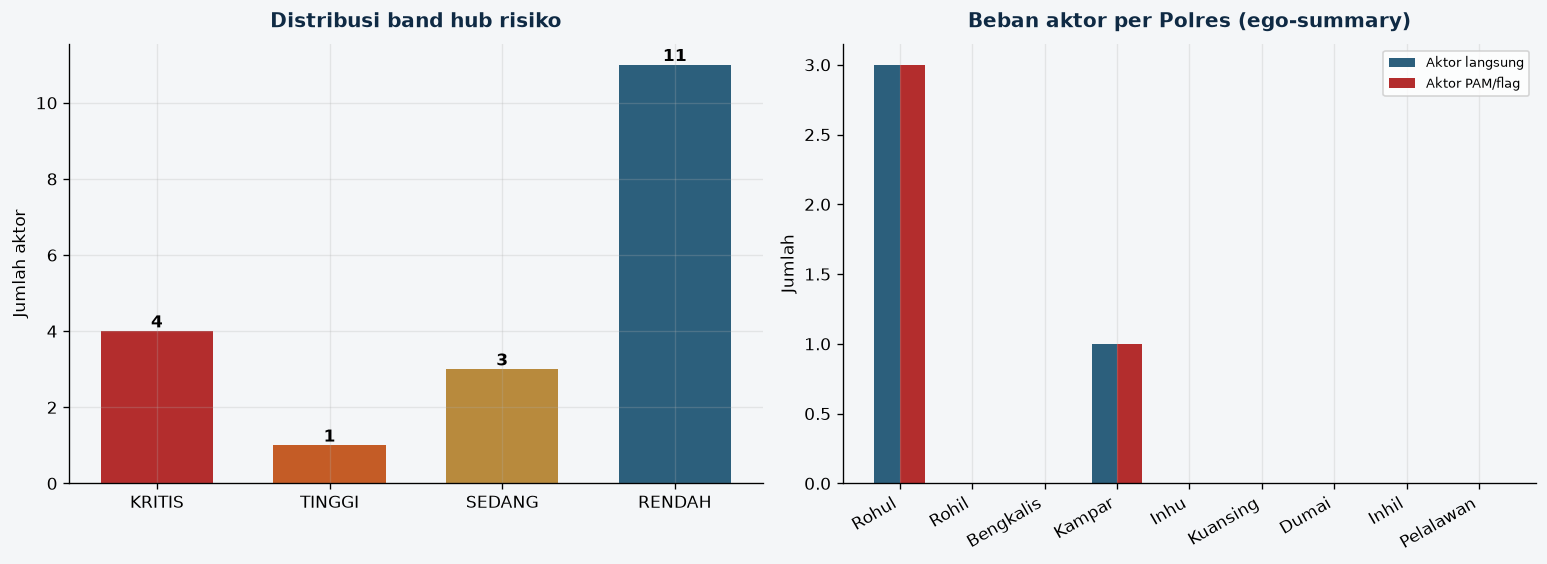

,polres,band_risiko,jml_aktor_langsung,jml_estate_langsung,estate_merah,aktor_pam_flag,aktor_contoh
0,Rohul,KRITIS,3,5,1,3,"Togas, Togos, Torus"
1,Rohil,TINGGI,0,1,1,0,
2,Bengkalis,TINGGI,0,3,1,0,
3,Kampar,SEDANG,1,7,0,1,Makmur Jaya Sentosa
4,Inhu,SEDANG,0,9,0,0,
5,Kuansing,SEDANG,0,2,0,0,
6,Dumai,SEDANG,0,2,0,0,
7,Inhil,RENDAH,0,2,0,0,
8,Pelalawan,RENDAH,0,11,0,0,


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), facecolor="#F4F6F8")
plot_band_distribution(hubs, ax=axes[0])
plot_ego_polres(ego, ax=axes[1])
fig.tight_layout()
fig.savefig(OUT / "fig_band_dan_ego_polres.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
ego


## 8. Heatmap aktor × Polres

Titik hitam = ada keterkaitan. Baris dengan banyak kolom = aktor multi-lokasi.


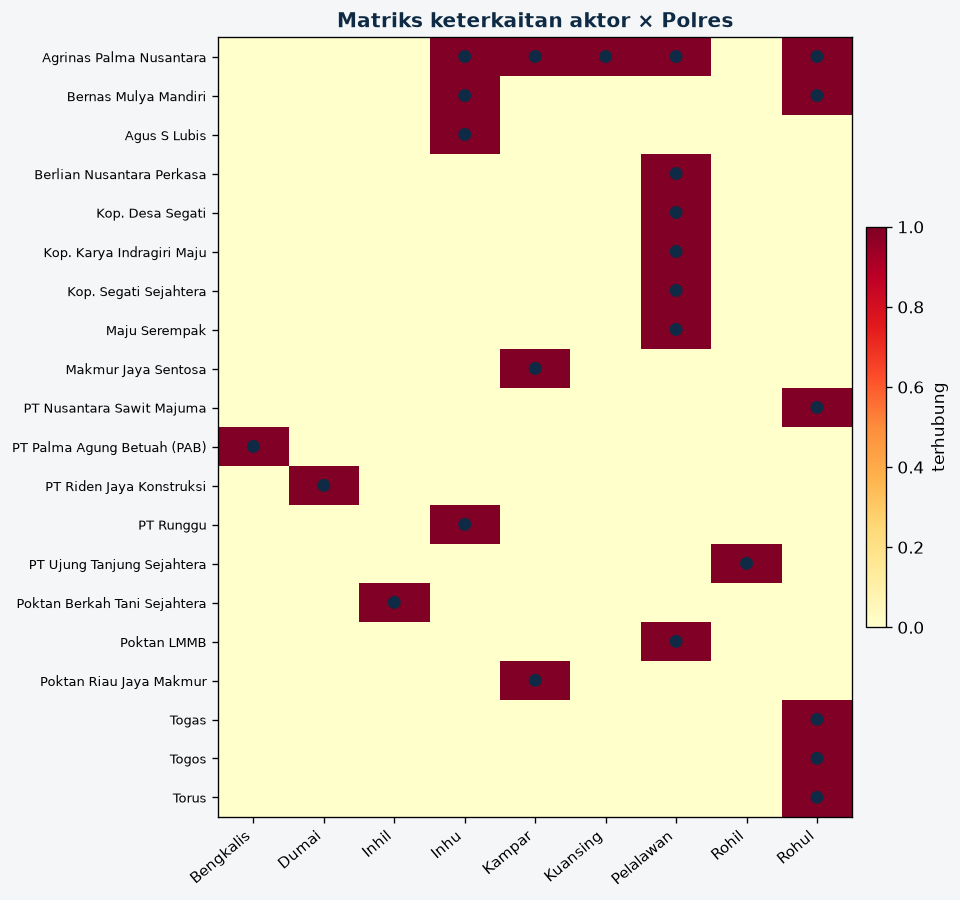

polres,Bengkalis,Dumai,Inhil,Inhu,Kampar,Kuansing,Pelalawan,Rohil,Rohul,total_polres
aktor,,,,,,,,,,
Agrinas Palma Nusantara,0,0,0,1,1,1,1,0,1,5
Bernas Mulya Mandiri,0,0,0,1,0,0,0,0,1,2
Agus S Lubis,0,0,0,1,0,0,0,0,0,1
Berlian Nusantara Perkasa,0,0,0,0,0,0,1,0,0,1
Kop. Desa Segati,0,0,0,0,0,0,1,0,0,1
Kop. Karya Indragiri Maju,0,0,0,0,0,0,1,0,0,1
Kop. Segati Sejahtera,0,0,0,0,0,0,1,0,0,1
Maju Serempak,0,0,0,0,0,0,1,0,0,1
Makmur Jaya Sentosa,0,0,0,0,1,0,0,0,0,1


In [8]:
fig = plot_heatmap_aktor_polres(mat)
fig.savefig(OUT / "fig_heatmap_aktor_polres.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
mat.sort_values("total_polres", ascending=False).head(15)


## 9. Peta jaringan fokus hub risiko

Node: Agrinas (pusat), aktor hub, estate, Polres.  
Warna mengikuti tipologi/klaster/band.


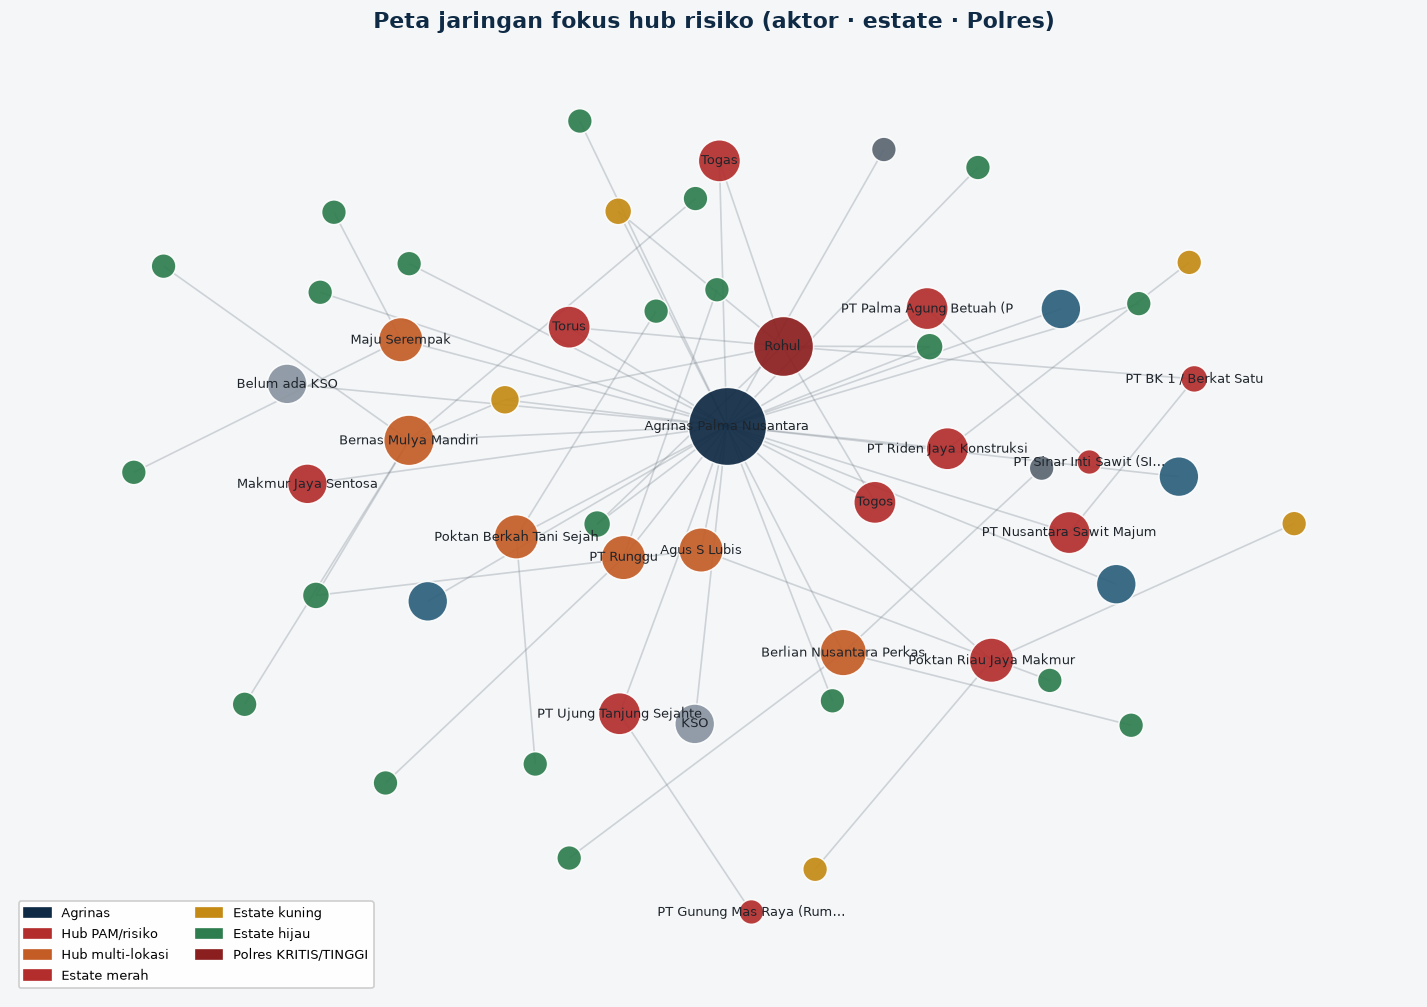

In [9]:
fig = plot_network(G, hubs, focus_hubs=True, seed=42)
fig.savefig(OUT / "fig_network_overview.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


## 10. Ego-network empat pilot bentrok (R4)

Inspeksi tetangga langsung: Majuma · PAB · UTS · Riden Jaya.


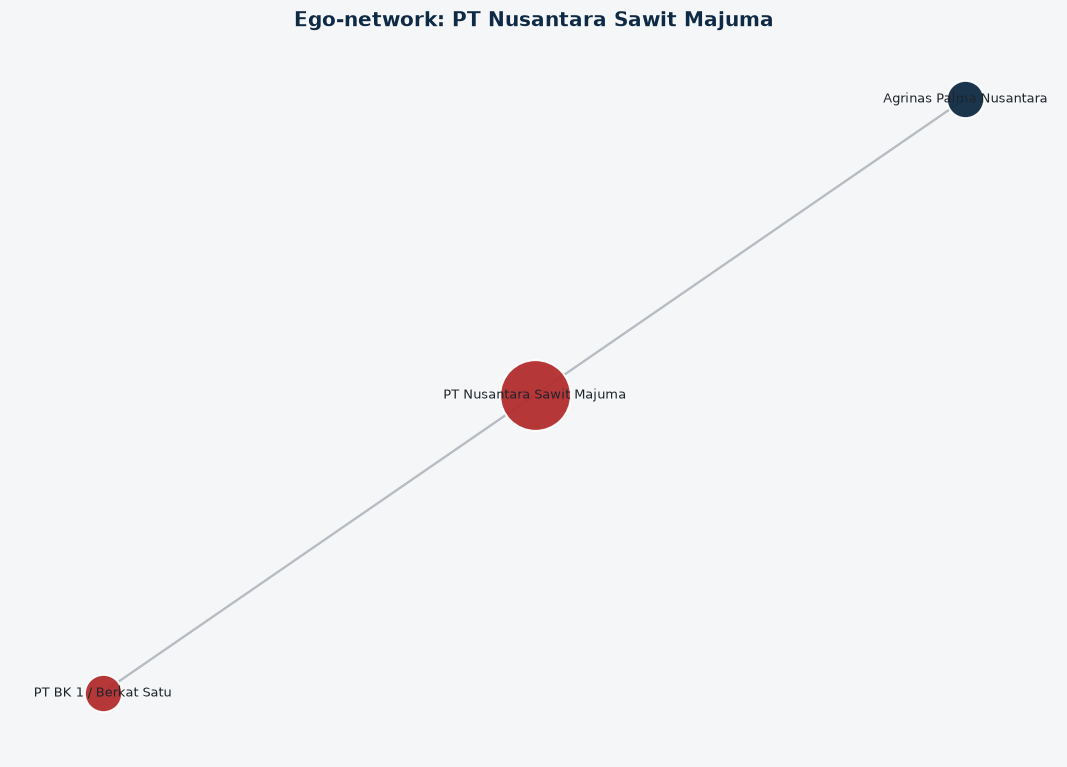

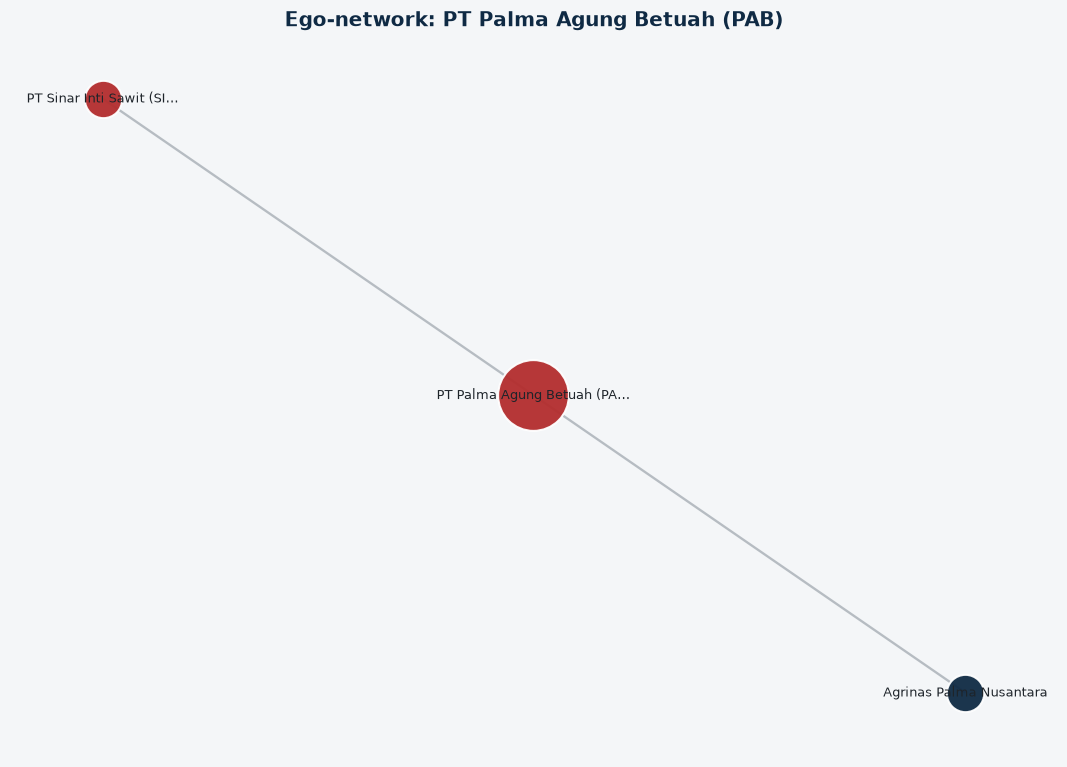

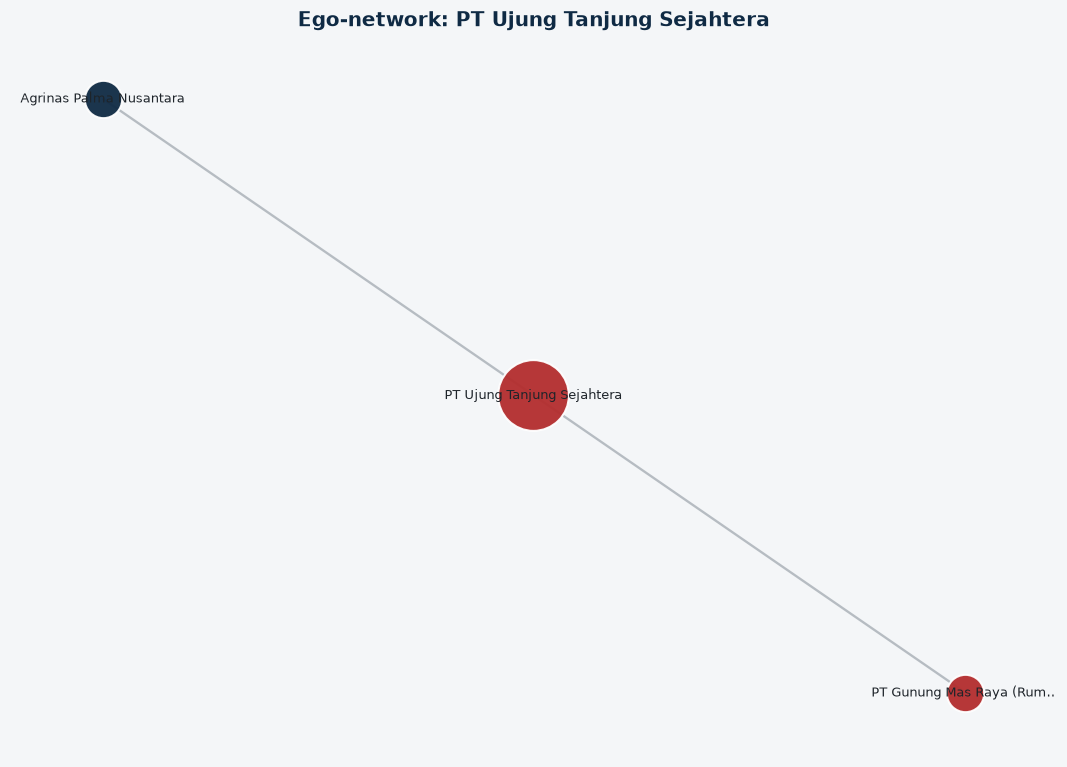

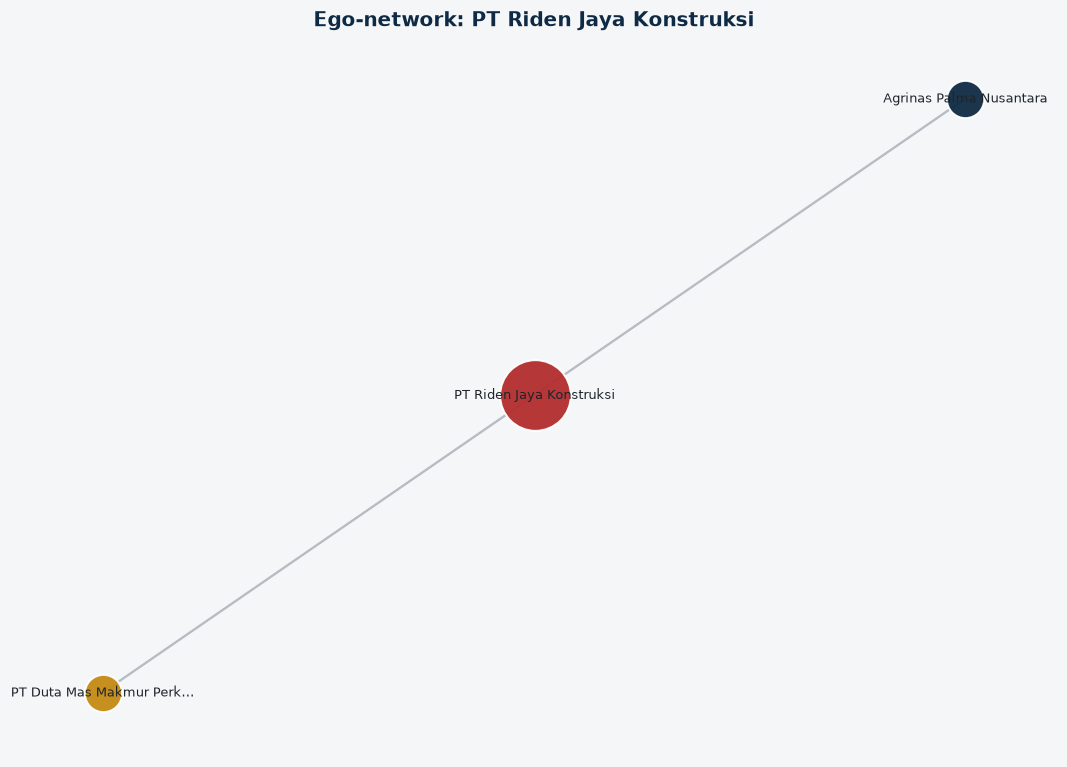

In [10]:
PILOT = [
    "PT Nusantara Sawit Majuma",
    "PT Palma Agung Betuah (PAB)",
    "PT Ujung Tanjung Sejahtera",
    "PT Riden Jaya Konstruksi",
]

for fokus in PILOT:
    fig = plot_ego_aktor(G, fokus)
    safe = fokus.replace("/", "-").replace(" ", "_")[:40]
    fig.savefig(OUT / f"fig_ego_{safe}.png", bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


## 11. Drill-down aktor (ubah `FOKUS` sesuai kebutuhan briefing)


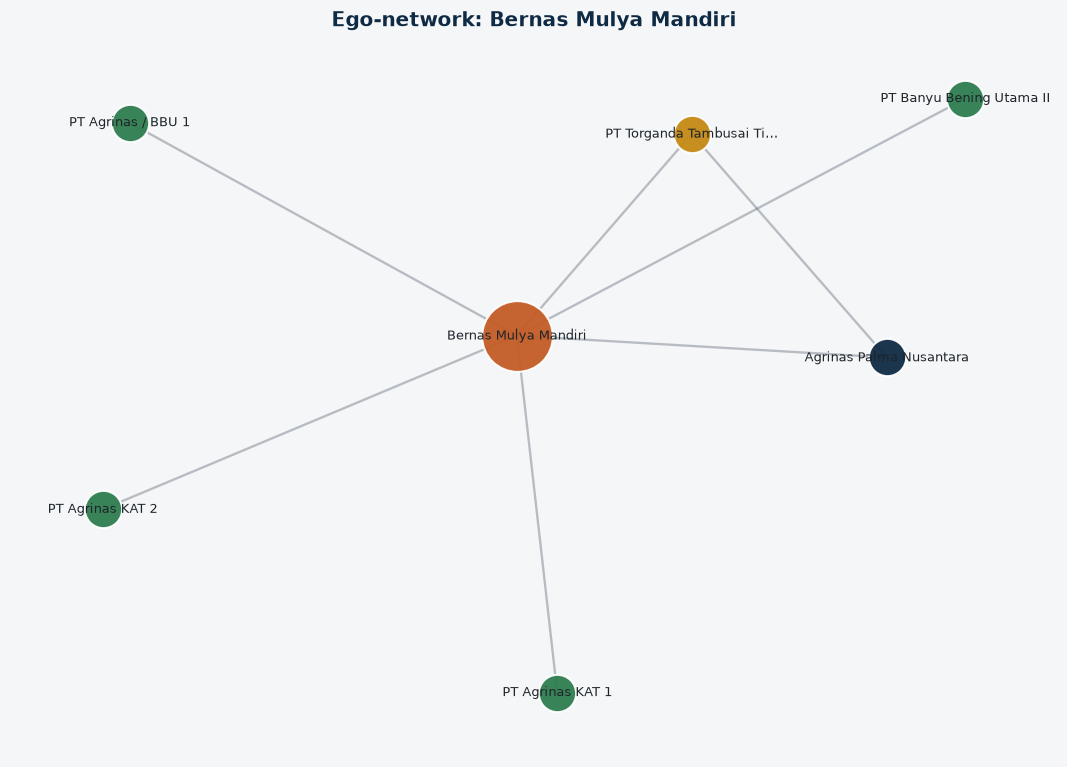

=== PROFIL ===
            aktor_id                label       ntype  skor_hub  skor_struktural  boost_dampak band_hub prioritas_pantau  degree  betweenness  jml_polres_terkait  jml_estate_tetangga  jml_estate_merah_tetangga pam_non_bujp_flag hub_risiko_flag polres_list        peran
Bernas Mulya Mandiri Bernas Mulya Mandiri aktor_multi      75.0             75.0           0.0   KRITIS               YA       6       0.0852                   2                    5                          0             TIDAK              YA Inhu, Rohul penerima_kso


,tetangga,ntype,klaster,polres,relasi,layer
0,Agrinas Palma Nusantara,agrinas,,,skema_agrinas,agrinas-aktor
1,PT Agrinas / BBU 1,estate_hijau,Hijau,Inhu,penerima_kso,aktor-estate
2,PT Agrinas KAT 1,estate_hijau,Hijau,Inhu,penerima_kso,aktor-estate
3,PT Agrinas KAT 2,estate_hijau,Hijau,Inhu,penerima_kso,aktor-estate
4,PT Banyu Bening Utama II,estate_hijau,Hijau,Inhu,penerima_kso,aktor-estate
5,PT Torganda Tambusai Timur,estate_kuning,Kuning,Rohul,penerima_kso,aktor-estate


In [11]:
FOKUS = "Bernas Mulya Mandiri"  # ganti: Majuma / PAB / UTS / Berlian / dll.

fig = plot_ego_aktor(G, FOKUS)
plt.show()

row = hubs[hubs["aktor_id"] == FOKUS]
print("=== PROFIL ===")
print(row.to_string(index=False) if len(row) else "Tidak ada di tabel hub")

rows = []
if FOKUS in G:
    for nb in sorted(G.neighbors(FOKUS)):
        d = G.nodes[nb]
        ed = G.edges[FOKUS, nb]
        rows.append({
            "tetangga": nb,
            "ntype": d.get("ntype"),
            "klaster": d.get("klaster"),
            "polres": d.get("polres") or (nb if str(d.get("ntype","")).startswith("polres") else ""),
            "relasi": ed.get("relasi"),
            "layer": ed.get("layer"),
        })
pd.DataFrame(rows)


## 12. Ekspor artefak Harda


In [12]:
OUT.mkdir(parents=True, exist_ok=True)
metrics.to_csv(OUT / "tabel_aktor_metrics.csv", index=False, encoding="utf-8-sig")
hubs.to_csv(OUT / "tabel_hub_risiko.csv", index=False, encoding="utf-8-sig")
ego.to_csv(OUT / "tabel_ego_polres.csv", index=False, encoding="utf-8-sig")
mat.to_csv(OUT / "matriks_aktor_polres.csv", encoding="utf-8-sig")
write_findings(hubs, metrics, ego, OUT / "ringkasan_temuan.md")

print("Artefak tersimpan di:", OUT)
for p in sorted(OUT.glob("*")):
    print(f" - {p.name} ({p.stat().st_size:,} byte)")

print("\n--- RINGKASAN TEMUAN ---")
print((OUT / "ringkasan_temuan.md").read_text(encoding="utf-8")[:1600])


Artefak tersimpan di: C:\Users\Patron\Downloads\sawit lagi\output\aktor_kso
 - fig_band_dan_ego_polres.png (70,043 byte)
 - fig_betweenness.png (79,658 byte)
 - fig_dashboard.png (227,562 byte)
 - fig_degree_hub.png (115,104 byte)
 - fig_ego_PT_Nusantara_Sawit_Majuma.png (54,166 byte)
 - fig_ego_PT_Palma_Agung_Betuah_(PAB).png (57,289 byte)
 - fig_ego_PT_Riden_Jaya_Konstruksi.png (56,388 byte)
 - fig_ego_PT_Ujung_Tanjung_Sejahtera.png (56,595 byte)
 - fig_heatmap_aktor_polres.png (115,091 byte)
 - fig_network_overview.png (347,187 byte)
 - fig_scatter_degree_betweenness.png (83,560 byte)
 - matriks_aktor_polres.csv (890 byte)
 - ringkasan_temuan.md (2,622 byte)
 - tabel_aktor_metrics.csv (9,626 byte)
 - tabel_ego_polres.csv (362 byte)
 - tabel_hub_risiko.csv (2,671 byte)

--- RINGKASAN TEMUAN ---
# Analisis Aktor Jaringan KSO Agrinas
**Unit II Harda — Ditreskrimum Polda Riau** · 4 Agustus 2026

## Ringkasan metodologi
- Graf sumber: `jaringan_kso_agrinas.gexf` (aktor–estate–Polres).
- 

## 13. Checklist baca visual untuk analis

| Visual | Pertanyaan yang dijawab |
|---|---|
| Skor hub | Siapa masuk watchlist bulan ini? |
| Betweenness | Siapa menjembatani banyak klaster? |
| Scatter degree×betweenness | Hub konektif vs hub jembatan? |
| Heatmap aktor×Polres | Siapa multi-lokasi? |
| Peta jaringan | Bagaimana Agrinas–KSO–estate–Polres terhubung? |
| Ego pilot | Tetangga langsung kasus bentrok? |

**Batasan:** graf dari cuplikan dokumen tersedia; skor = alat prioritisasi analitik, bukan bukti pidana.

---
*Unit II Harda · Ditreskrimum Polda Riau*
